In [1]:
try:
    from myfm import MyFMClassifier, MyFMGibbsClassifier, VariationalFMClassifier
    # from myfm.utils.encoders import DataFrameEncoder
except:
    !pip install -q myfm
    from myfm import MyFMClassifier, MyFMGibbsClassifier, VariationalFMClassifier
    # from myfm.utils.encoders import DataFrameEncoder

try:
    from fastFM.als import FMClassification as als_Classification
    from fastFM.sgd import FMClassification as sgd_Classification
except:
    !pip install -q fastFM
    from fastFM.als import FMClassification as als_Classification
    from fastFM.sgd import FMClassification as sgd_Classification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.stats import norm

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder as sklearnTE

In [5]:
# !uv pip install -U scikit-learn

In [6]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [7]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = 'Will_Buy_EV'
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 15)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [8]:
display(train.head())
train.info()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103210,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0
Will_Buy_EV,668665.0,0.174645,0.379663,0.0,0.0,0.0,0.0,1.0


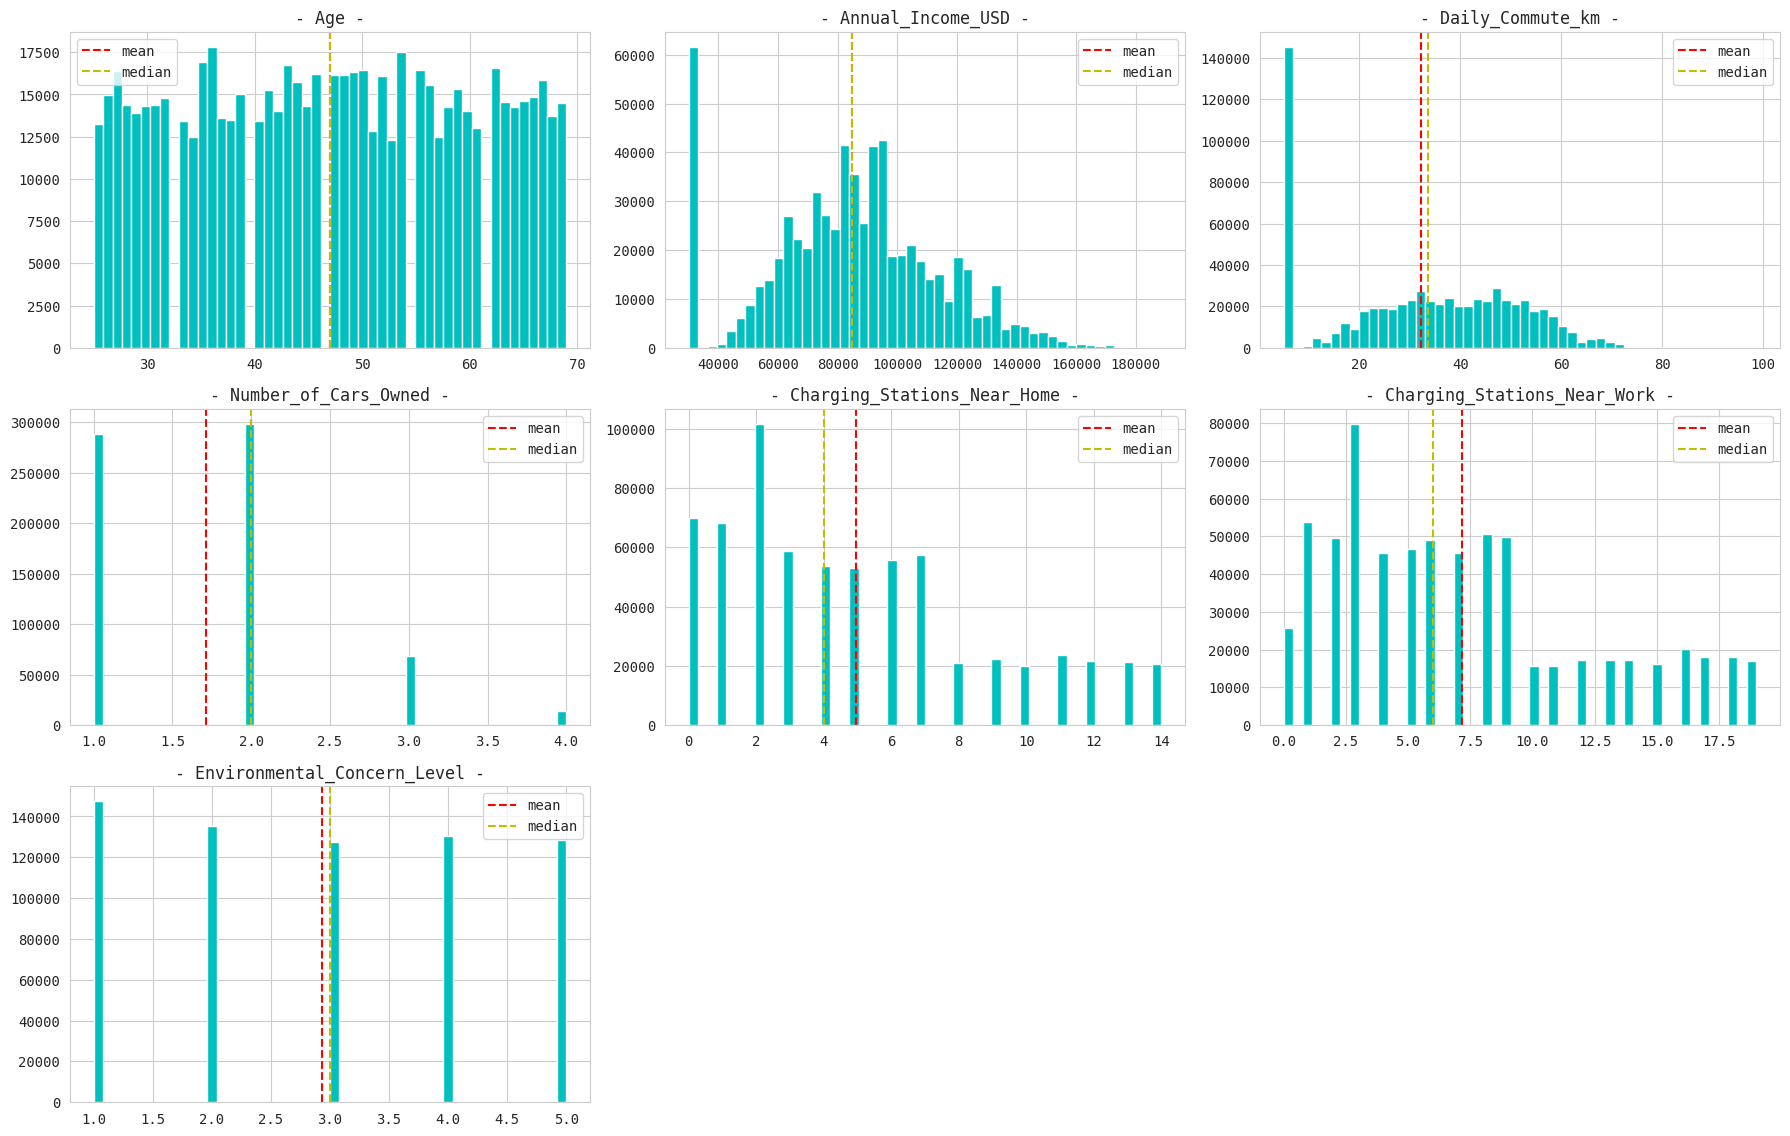

In [10]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
Home_Charging_Possible,2,2,2
Subsidy_Available,2,2,2
Gender,3,3,3
City_Type,3,3,3
Range_Anxiety_Level,3,3,3
Number_of_Cars_Owned,4,4,4
Current_Car_Type,4,4,4
Environmental_Concern_Level,5,5,5
Charging_Stations_Near_Home,15,15,15
Charging_Stations_Near_Work,20,20,20


In [12]:
n_unique = train[BASE].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
Gender                             3
City_Type                          3
Range_Anxiety_Level                3
Number_of_Cars_Owned               4
Current_Car_Type                   4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

## FEATURE ENGINEERING

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class customTE(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [14]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [15]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# aggs_ = ["mean", "count"]

# train, orig_cols = original_TE(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=aggs_,
#     # fill_nan=True,
# )

# test, _ = original_TE(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=aggs_,
#     # fill_nan=True,
# )

# train[orig_cols][:10].T

In [16]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Old Features:", len(FEATURES))

combined = pd.concat([train, test]) # , orig
## ------------------------------------------------------------
# # -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS, title="nums_to_cats"):
#     n = f"{c}_cat"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
# FEATURES.extend(CATS_2)
## ------------------------------------------------------------
## -- Factorize all features --
for c in tqdm(CATS, desc="factorize_cats"):
    combined[c] = combined[c].factorize()[0]

# for c in tqdm(CATS, desc="categorize_cats"):
#     combined[c] = combined[c].astype("category")
print("Label encoding complete!")

digits_cols = []
cols_select = [
    "Annual_Income_USD", "Daily_Commute_km", "Age"
    # "Charging_Stations_Near_Home", "Charging_Stations_Near_Work"
]
for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][FEATURES+[TARGET]+digits_cols]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES+digits_cols]
# orig  = combined.iloc[len(train)+len(test):]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("New Features:", len(FEATURES))

del combined

train

Old Features: 13


factorize_cats: 100%|██████████| 6/6 [00:00<00:00, 13.93it/s]


Label encoding complete!
New Features: 22


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.0,7,8,8,2,4,3,2,6,6
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.0,0,0,0,0,0,5,0,8,3
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.0,9,8,3,4,8,6,3,6,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.0,0,8,5,3,7,3,2,6,6
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.0,8,9,8,7,8,0,5,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.0,0,9,0,1,4,7,2,0,3
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.0,0,9,9,9,0,5,0,2,3
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.0,1,9,7,1,2,4,2,4,6
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.0,3,2,9,5,7,3,4,1,5


In [17]:
train.nunique()

Age                               45
Annual_Income_USD              13214
Daily_Commute_km                 805
Number_of_Cars_Owned               4
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Environmental_Concern_Level        5
Gender                             3
City_Type                          3
Current_Car_Type                   4
Home_Charging_Possible             2
Subsidy_Available                  2
Range_Anxiety_Level                3
Will_Buy_EV                        2
Annual_Income_USD_digit0          10
Annual_Income_USD_digit1          10
Annual_Income_USD_digit2          10
Annual_Income_USD_digit3          10
Daily_Commute_km_digit-1          10
Daily_Commute_km_digit0           10
Daily_Commute_km_digit1           10
Age_digit0                        10
Age_digit1                         5
dtype: int64

# ML TRAINING

In [18]:
y_ = np.ascontiguousarray(train[TARGET], dtype=np.float64)
_y = np.where(train[TARGET] == 1, 1, -1)

print(np.unique(y_), np.unique(_y))
print(y_[:5], _y[:5])

[0. 1.] [-1  1]
[0. 0. 1. 0. 0.] [-1 -1  1 -1 -1]


In [19]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, use_ohe=False, use_original=False):
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()

    oof_preds  = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    fold_scores = []
    feature_importances  = []

    # Handle optional original table aggregations securely if flags enable them
    if use_original and "original_TE" in globals():
        feats = features.copy()
        # "mean" for bagging | ("mean", "count", "std", "skew") for goss
        aggs_ = ["mean", "count"] 

        X_tr, orig_cols = original_TE(
            orig, train_data, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_df[features]
        y = train_df[target].astype("int8")
        X_ts = test_df[features]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n+++++ FOLD {idx}/{kfold.n_splits}")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        if idx == 1:
            display(X_train.head())

        print(f"   ⚙️ -> Shape: {X_train.shape}", end=" | ")

        rank = params["rank"]
        # -- Expose encoder's categories for info filtering --
        if use_ohe:
            keep = 200
            print(f"One-Hot-Encoding * Rank={rank} * Keep={keep}")
            ohe_ = OneHotEncoder(handle_unknown='ignore').fit(X_train)
            transformed_valid = ohe_.transform(X_valid)

            group_shapes = [len(group) for group in ohe_.categories_]
            print(f"   ⚙️ -> Group shapes: {group_shapes}")
        else:
            keep = 10
            print(f"Scaling raw features * Rank={rank} * Keep={keep}")
            scaler = StandardScaler().fit(X_train)
            transformed_valid = scaler.transform(X_valid)

            group_shapes = [i for i, col in enumerate(X_train.columns)]
            print(f"   ⚙️ -> Column indicators: {group_shapes}")

        # -------------------------------------------------------------------------------
        if "myfm" in model_name:
            myfm_params = {'rank': rank, 'init_stdev': params["init_stdev"], 'random_seed': 42}
            model_type  = "myfm_gibbs" if "gibbs" in model_name else "myfm_var"
            model = Pipeline(
                [
                    ("ohe", OneHotEncoder(handle_unknown='ignore')) if use_ohe else ("sca", StandardScaler()),
                    (
                        model_type, MyFMClassifier(**myfm_params),
                    ) if "gibbs" in model_name else (
                        model_type, VariationalFMClassifier(**myfm_params),
                    )
                ],
                verbose=True,
            )
            print(f"   ⚙️ -> Training model: '{model_name}' ...\n")
            model.fit(**{
                'X': X_train,
                'y': y_train.values,
                f"{model_type}__X_test": transformed_valid,
                f"{model_type}__y_test": y_valid.values,
                f"{model_type}__n_iter": params["n_iter"],
                f"{model_type}__n_kept_samples": keep,
                f"{model_type}__grouping": None if use_ohe else group_shapes,
                f"{model_type}__group_shapes": group_shapes if use_ohe else None,
            } if "gibbs" in model_name else {
                'X': X_train,
                'y': y_train.values,
                f"{model_type}__X_test": transformed_valid,
                f"{model_type}__y_test": y_valid.values,
                f"{model_type}__n_iter": params["n_iter"],
                # f"{model_type}__n_kept_samples": keep,
                f"{model_type}__grouping": None if use_ohe else group_shapes,
                f"{model_type}__group_shapes": group_shapes if use_ohe else None,
            })
        elif "fastfm_als" in model_name:
            model = Pipeline(
                [
                    ("ohe", OneHotEncoder(handle_unknown='ignore')),
                    ("fast_als", als_Classification(**params, random_state=42)),
                ],
                verbose=True,
            )
            y_train = np.where(y_train == 1, 1.0, -1.0)
            print(f"   ⚙️ -> Training model: '{model_name}' ...\n")
            model.fit(X_train, y_train)
        else:
            model = Pipeline(
                [
                    ("ohe", OneHotEncoder(handle_unknown='ignore')),
                    ("fast_sgd", sgd_Classification(**params)),
                ],
                verbose=True,
            )
            y_train = np.where(y_train == 1, 1.0, -1.0)
            print(f"   ⚙️ -> Training model: '{model_name}' ...")
            model.fit(X_train, y_train)
        # -------------------------------------------------------------------------------

        oof_preds[val_idx] = model.predict_proba(X_valid)
        test_preds += model.predict_proba(X_test) / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del X_test, model
        gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits
    
    ## -- CV results --
    print("\n========================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("========================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("---------------------------------------")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("---------------------------------------")
    print(f"{(time()-t0)/60:.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        # 'model': model,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [20]:
all_predictions = {}

FOLDS = 10
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.0,7,8,8,2,4,3,2,6,6
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.0,0,0,0,0,0,5,0,8,3
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.0,9,8,3,4,8,6,3,6,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.0,0,8,5,3,7,3,2,6,6
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.0,8,9,8,7,8,0,5,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.0,0,9,0,1,4,7,2,0,3
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.0,0,9,9,9,0,5,0,2,3
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.0,1,9,7,1,2,4,2,4,6
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.0,3,2,9,5,7,3,4,1,5


In [21]:
# try:
#     import optuna
# except:
#     !pip install -q optuna
#     import optuna

# def objective(trial):
#     params = {
#         "n_iter": 100,
#         "rank": 4,
#         "init_stdev": trial.suggest_float("init_stdev", 0.01, 3.0),
#         "l2_reg_w": trial.suggest_float("l2_reg_w", 0.01, 3.0),
#         "l2_reg_V": trial.suggest_float("l2_reg_V", 0.01, 3.0),
#         "l2_reg": trial.suggest_float("l2_reg", 0.01, 3.0),
#         "random_state": 42,
#     }

#     # "ffm_fastFM_als", "ffm_fastFM_sgd"
#     n = "ffm_fastFM_als"

#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         # use_original=True,
#     )
#     return all_predictions[n]["score"]

# print("Optuna search ready!")

# # Create the study and run optimization
# study = optuna.create_study(direction="maximize", study_name="Optuna_Search")

# # Run optimization for 50 trials
# study.optimize(objective, n_trials=20, timeout=3600, show_progress_bar=True, gc_after_trial=True)

In [22]:
# print("\n--- Optimization Complete ---")
# print(f"Best Trial ROC-AUC Score: {study.best_value:.6f}")
# print("Best Hyperparameters:")
# study.best_params

# # Default learning_rate: 0.04 --
# # --- Optimization Complete ---
# # Best Trial ROC-AUC Score: 0.965555
# # Best Hyperparameters:
# # {'depth': 6, 'temperature': 0.3, 'l2_reg': 0.10348352129966662}

# # --- Optimization Complete ---
# # Best Trial ROC-AUC Score: 0.965525
# # Best Hyperparameters:
# # {'depth': 5, 'temperature': 0.4, 'strength': 0.6, 'l2_reg': 1.2224361482015358}

In [23]:
# ## -- Visualize parameter importance
# optuna.visualization.plot_param_importances(study).show()

# ## -- Optimization history across trials
# optuna.visualization.plot_slice(study).show()

# ## -- Optimization history --
# optuna.visualization.plot_optimization_history(study).show()

In [24]:
# ## --- Trainer --- v1_myFM_gibbs_rank2, v1_fastFM_als_rank2

# USE_ONE_HOT_ENCODING = False

# params = {
#     "rank": 1 if USE_ONE_HOT_ENCODING else 4,
#     "n_iter": 300,
#     "init_stdev": 0.2 if USE_ONE_HOT_ENCODING else 0.1, # 0.1, 0.2, 0.5, 1.0
#     "l2_reg_w": 1.0, # 0.1
#     "l2_reg_V": 1.0, # 0.5
#     "l2_reg": 1.0, # 1.0
# }

# # f"fm_myfm_gibbs{params["rank"]}", f"fm_myfm_var{params["rank"]}"
# # f"fm_fastfm_als{params["rank"]}", f"fm_fastfm_sgd{params["rank"]}"

# for n in [f"fm_myfm_gibbs{params["rank"]}", f"fm_myfm_var{params["rank"]}"]:
#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         use_ohe=USE_ONE_HOT_ENCODING,
#         # use_original=True,
#     )

In [25]:
## --- Trainer ---

# f"fm_myfm_gibbs{params["rank"]}", f"fm_myfm_var{params["rank"]}"
# f"fm_fastfm_als{params["rank"]}", f"fm_fastfm_sgd{params["rank"]}"

for USE_ONE_HOT in [True, False]:
    N_ITER   = 300
    RANK     = 1 if USE_ONE_HOT else 4
    INIT_STD = 0.2 if USE_ONE_HOT else 0.1
    
    for n in [f"fm_myfm_gibbs{RANK}", f"fm_myfm_var{RANK}"]:
        params = {
            "rank": RANK,
            "n_iter": N_ITER,
            "init_stdev": INIT_STD, # 0.1, 0.2, 0.5, 1.0
            "l2_reg_w": 1.0, # 0.1
            "l2_reg_V": 1.0, # 0.5
            "l2_reg": 1.0, # 1.0
        }
        all_predictions[n] = Trainer_CV(
            model_name=n,
            params=params,
            train_df=train_data,
            test_df=test,
            features=FEATURES,
            target=TARGET,
            kfold=skf,
            use_ohe=USE_ONE_HOT,
            # use_original=True,
        )


===== Starting CV: fm_myfm_gibbs1 | CPU: 4 =====

+++++ FOLD 1/10


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,7,8,8,2,4,3,2,6,6
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0,8,5,3,7,3,2,6,6
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,8,9,8,7,8,0,5,4,5
5,50,95938.0,55.1,2,8,15,3.0,2,2,0,1,0,0,8,3,9,5,1,5,5,0,5
6,55,109219.0,42.9,1,1,5,4.0,0,0,0,0,1,0,9,1,2,9,9,2,4,5,5


   ⚙️ -> Shape: (601798, 22) | One-Hot-Encoding * Rank=1 * Keep=200
   ⚙️ -> Group shapes: [45, 12837, 798, 4, 15, 20, 5, 3, 3, 4, 2, 2, 3, 10, 10, 10, 10, 10, 10, 10, 10, 5]
   ⚙️ -> Training model: 'fm_myfm_gibbs1' ...

[Pipeline] ............... (step 1 of 2) Processing ohe, total=   1.4s


w0 = -2.58  ll_this: 0.23 accuracy_this: 0.90: 100%|██████████| 300/300 [02:21<00:00,  2.13it/s]


[Pipeline] ........ (step 2 of 2) Processing myfm_gibbs, total= 2.4min
 • Fold 1 AUC: 0.942871

+++++ FOLD 2/10
   ⚙️ -> Shape: (601798, 22) | One-Hot-Encoding * Rank=1 * Keep=200
   ⚙️ -> Group shapes: [45, 12831, 800, 4, 15, 20, 5, 3, 3, 4, 2, 2, 3, 10, 10, 10, 10, 10, 10, 10, 10, 5]
   ⚙️ -> Training model: 'fm_myfm_gibbs1' ...

[Pipeline] ............... (step 1 of 2) Processing ohe, total=   1.4s


...

[Pipeline] .......... (step 2 of 2) Processing myfm_var, total= 6.7min
 • Fold 8 AUC: 0.939526

+++++ FOLD 9/10
   ⚙️ -> Shape: (601799, 22) | Scaling raw features * Rank=4 * Keep=10
   ⚙️ -> Column indicators: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
   ⚙️ -> Training model: 'fm_myfm_var4' ...

[Pipeline] ............... (step 1 of 2) Processing sca, total=   0.2s


w0 = -1.72  ll_this: 0.23 accuracy_this: 0.90: 100%|██████████| 300/300 [06:42<00:00,  1.34s/it]


[Pipeline] .......... (step 2 of 2) Processing myfm_var, total= 6.7min
 • Fold 9 AUC: 0.939560

+++++ FOLD 10/10
   ⚙️ -> Shape: (601799, 22) | Scaling raw features * Rank=4 * Keep=10
   ⚙️ -> Column indicators: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
   ⚙️ -> Training model: 'fm_myfm_var4' ...

[Pipeline] ............... (step 1 of 2) Processing sca, total=   0.2s


w0 = -1.72  ll_this: 0.23 accuracy_this: 0.89: 100%|██████████| 300/300 [06:41<00:00,  1.34s/it]


[Pipeline] .......... (step 2 of 2) Processing myfm_var, total= 6.7min
 • Fold 10 AUC: 0.937683

10-FOLD CV: fm_myfm_var4 | (601799, 22)
 • Fold 1 AUC: 0.937380
 • Fold 2 AUC: 0.936957
 • Fold 3 AUC: 0.938337
 • Fold 4 AUC: 0.938808
 • Fold 5 AUC: 0.939493
 • Fold 6 AUC: 0.939710
 • Fold 7 AUC: 0.938902
 • Fold 8 AUC: 0.939526
 • Fold 9 AUC: 0.939560
 • Fold 10 AUC: 0.937683
---------------------------------------
Overall AUC: 0.938634
Average AUC: 0.938636 ± 0.000950
---------------------------------------
67.39 mins



In [26]:
# raw features rank=4 | keep=10 | n_iter=300 | init_stdev=0.1
# ========================================
# 5-FOLD CV: fm_myfm_gibbs4 | (534932, 22)
# ========================================
#  • Fold 1 AUC: 0.937061
#  • Fold 2 AUC: 0.938566
#  • Fold 3 AUC: 0.939553
#  • Fold 4 AUC: 0.939193
#  • Fold 5 AUC: 0.938628
# ---------------------------------------
# Overall AUC: 0.938599
# Average AUC: 0.938600 ± 0.000852
# ---------------------------------------
# 17.56 mins

# ========================================
# 5-FOLD CV: fm_myfm_var4 | (534932, 22)
# ========================================
#  • Fold 1 AUC: 0.937142
#  • Fold 2 AUC: 0.938576
#  • Fold 3 AUC: 0.939574
#  • Fold 4 AUC: 0.939246
#  • Fold 5 AUC: 0.938619
# ---------------------------------------
# Overall AUC: 0.938629
# Average AUC: 0.938631 ± 0.000835
# ---------------------------------------
# 30.05 mins

# one-hot-enc -> rank=1 | n_iter=300 | n_keep=200 | init_stdev=0.2
# ========================================
# 5-FOLD CV: fm_myfm_gibbs1 | (534932, 22)
# ========================================
#  • Fold 1 AUC: 0.942152
#  • Fold 2 AUC: 0.943132
#  • Fold 3 AUC: 0.944157
#  • Fold 4 AUC: 0.943098
#  • Fold 5 AUC: 0.943415
# ---------------------------------------
# Overall AUC: 0.943188
# Average AUC: 0.943191 ± 0.000644
# ---------------------------------------
# 11.98 mins

# ========================================
# 5-FOLD CV: fm_myfm_var1 | (534932, 22)
# ========================================
#  • Fold 1 AUC: 0.941327
#  • Fold 2 AUC: 0.942387
#  • Fold 3 AUC: 0.943394
#  • Fold 4 AUC: 0.942418
#  • Fold 5 AUC: 0.942516
# ---------------------------------------
# Overall AUC: 0.942382
# Average AUC: 0.942408 ± 0.000656
# ---------------------------------------
# 17.16 mins

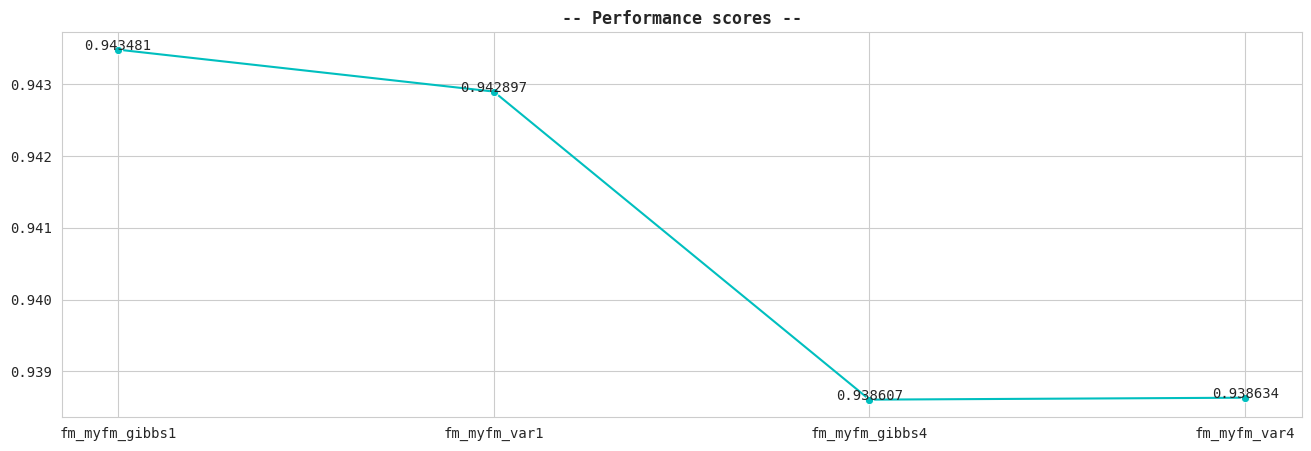

In [27]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("-- Performance scores --", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

# plt.tight_layout()
plt.show()

fm_myfm_gibbs1_943481 saved!


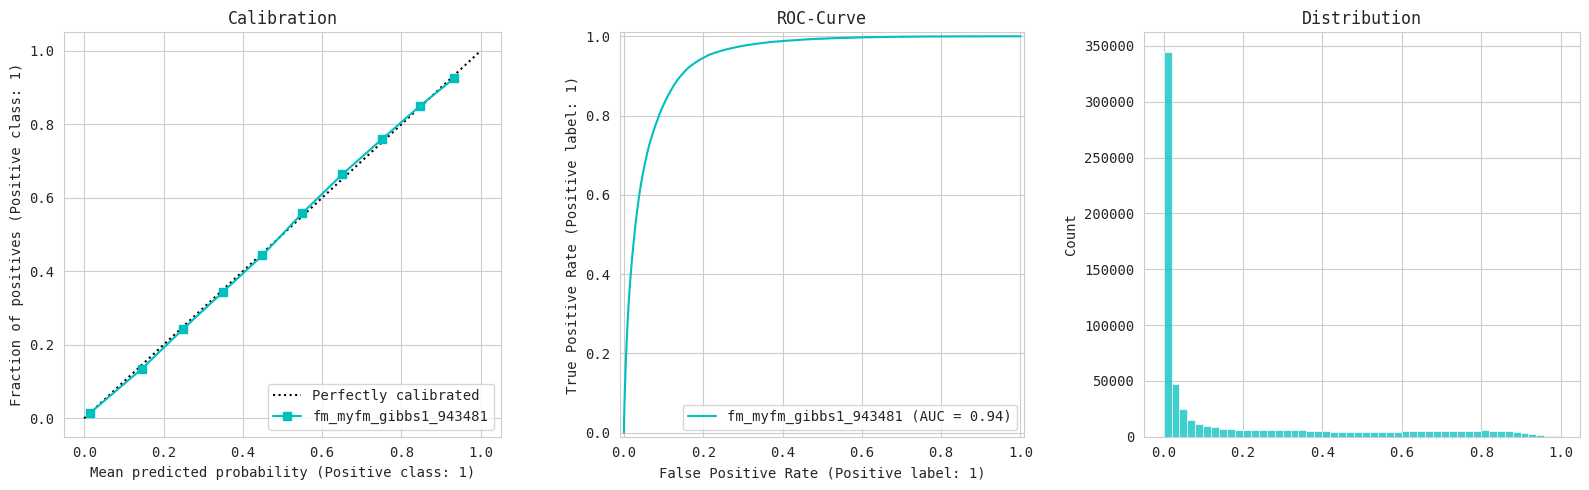


fm_myfm_var1_942897 saved!


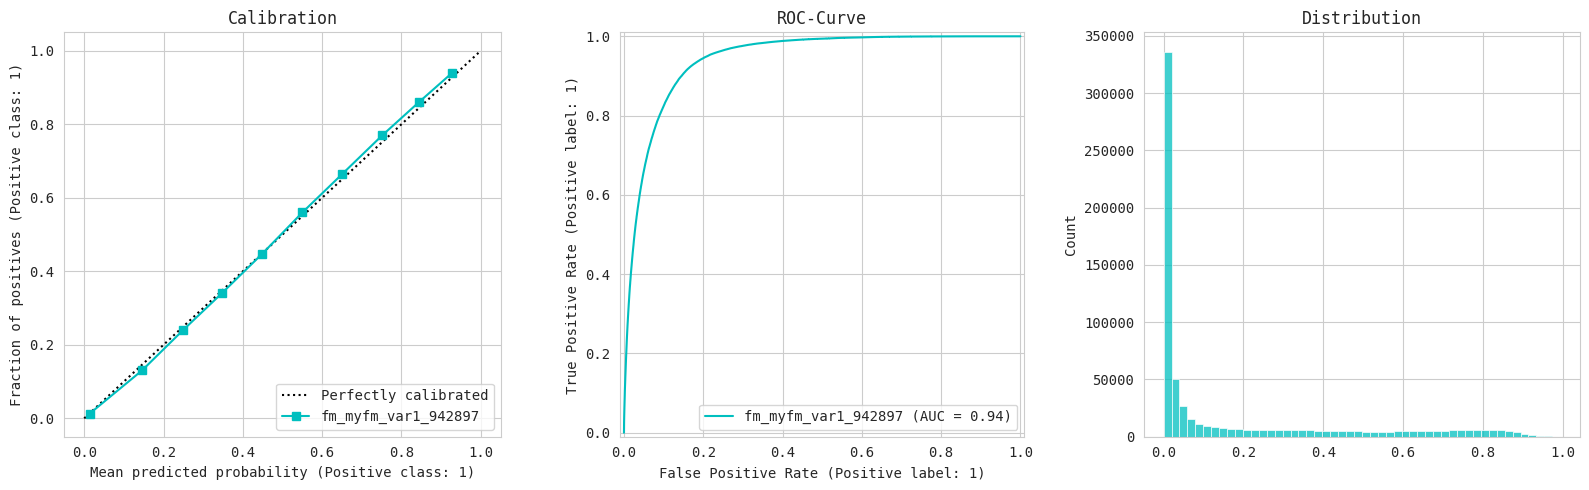


fm_myfm_gibbs4_938607 saved!


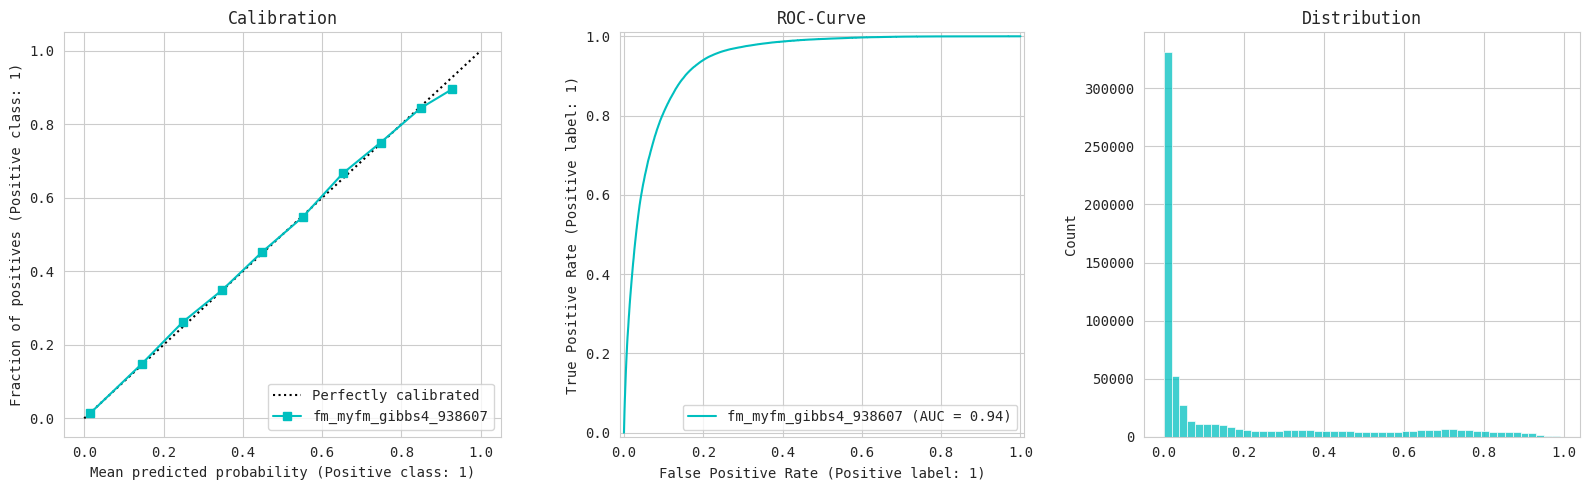


fm_myfm_var4_938634 saved!


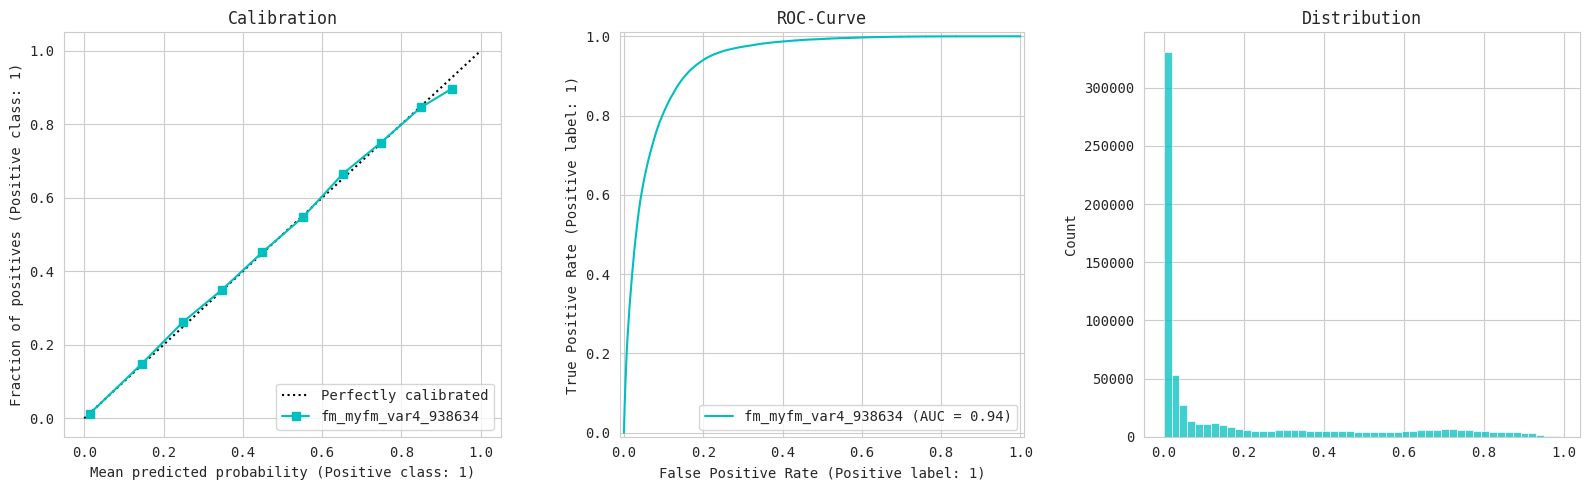

In [28]:
## -- Get oof predictions --

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [29]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n:>25} saved! {y.shape}")

            model_results[n[:-7]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

    fm_myfm_gibbs1_943481 saved! (286571,)
      fm_myfm_var1_942897 saved! (286571,)
    fm_myfm_gibbs4_938607 saved! (286571,)
      fm_myfm_var4_938634 saved! (286571,)



,fm_myfm_gibbs1,fm_myfm_var1,fm_myfm_gibbs4,fm_myfm_var4
0,0.067629,5.336532e-02,0.009089,0.010338
1,0.011918,1.381649e-02,0.026453,0.028036
2,0.000396,6.205267e-04,0.006294,0.006453
3,0.003772,5.435183e-03,0.004016,0.003715
4,0.036553,3.438940e-02,0.015305,0.016454
...,...,...,...,...
286566,0.000013,3.060520e-06,0.000183,0.000189
286567,0.362217,3.305471e-01,0.146125,0.147708
286568,0.000997,3.704927e-03,0.002945,0.003214
286569,0.000407,2.265776e-05,0.000141,0.000161


In [30]:
model_results.describe().T

,count,mean,std,min,25%,50%,75%,max
fm_myfm_gibbs1,286571.0,0.174896,0.270227,2.916971e-08,0.001160,0.017557,0.270739,0.996979
fm_myfm_var1,286571.0,0.174550,0.266058,5.447420e-13,0.001167,0.019649,0.274453,0.994220
fm_myfm_gibbs4,286571.0,0.174529,0.265921,1.286471e-05,0.002480,0.020943,0.267656,0.990293
fm_myfm_var4,286571.0,0.174588,0.265965,8.946912e-06,0.002448,0.021020,0.268144,0.989594


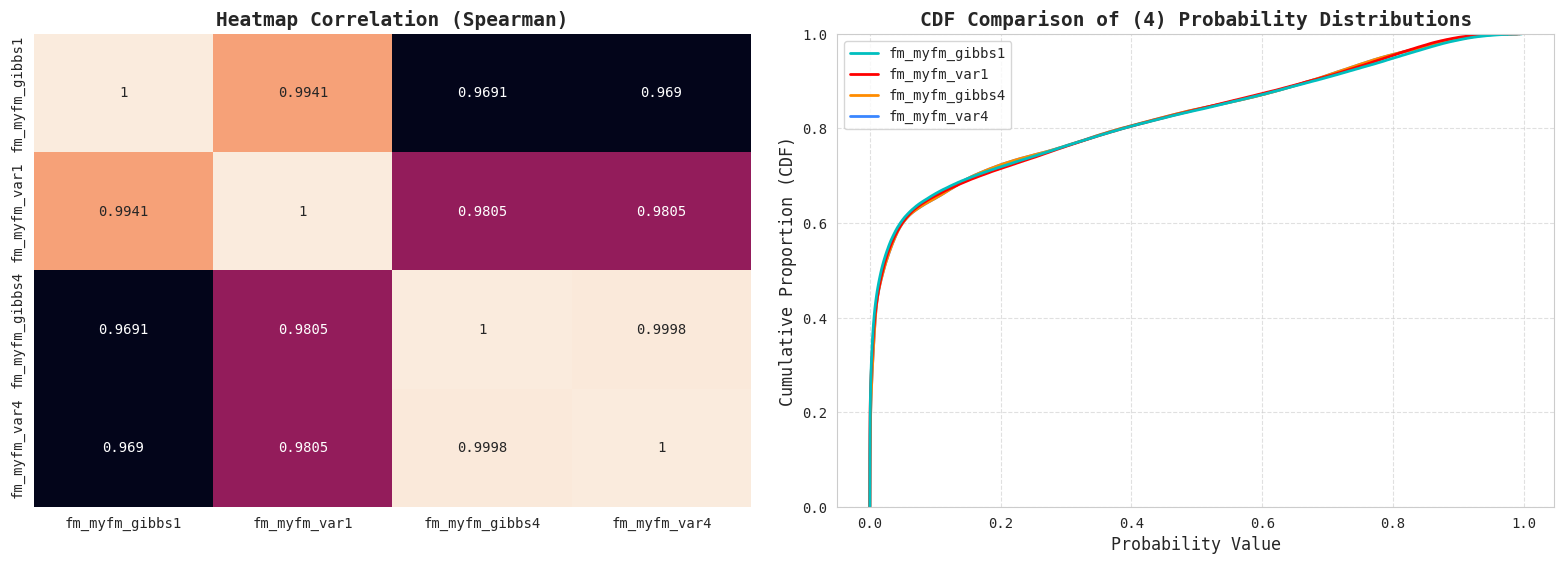

In [31]:
mdls = model_results.shape[1]

if mdls > 1:
    # display(model_results.corr("spearman"))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(model_results.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
    ax1.set_title('Heatmap Correlation (Spearman)', fontsize=14, fontweight='bold')
    
    sns.ecdfplot(data=model_results, linewidth=2, ax=ax2)
    ax2.set_title(f"CDF Comparison of ({mdls}) Probability Distributions", fontsize=14, fontweight='bold')
    ax2.set_xlabel('Probability Value', fontsize=12)
    ax2.set_ylabel('Cumulative Proportion (CDF)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(pad=2.0)
    plt.show()

In [32]:
# !rm -r /kaggle/working